# VR Chinese OCR — Final Analysis

**Course:** Deep Learning for Media (MPATE-GE 2039 / DM-GY 9103)  
**Task:** Representation Analysis  
**Question:** How robust are OCR models for handwritten Chinese characters under VR-specific distortions?

### Models compared
| Model | Type |
|---|---|
| ANCHOR | VGG-like CNN trained on CASIA handwriting |
| PaddleOCR | Baidu production OCR system |
| EasyOCR | CRAFT + CRNN open-source |
| CnOCR | Lightweight Chinese OCR |
| Apple Vision | macOS on-device OCR (VNRecognizeTextRequest) |

### Dataset
CASIA-HWDB — offline handwritten Chinese characters.  
Test set: clean images + 9 VR-simulated perturbation types.

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from sklearn.metrics import confusion_matrix

from evaluation.metrics import evaluate
from evaluation.accuracy_curves import (
    plot_accuracy_by_perturbation,
    plot_robustness_gap_heatmap,
    plot_robustness_gap_bars,
    plot_clean_comparison,
    plot_f1_by_perturbation,
    plot_overall_metrics,
    _color,
)
from evaluation.failure_analysis import show_failures, confusion_summary, compare_model_failures
from evaluation.utils import print_results_table, print_perturbation_table, print_robustness_table

DATA_DIR = "data"
OUT_DIR  = "../outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# Set a CJK-capable font so Chinese characters render correctly in all figures
_CJK_FONTS = ["Hiragino Sans GB", "Arial Unicode MS", "PingFang SC", "Heiti SC", "STHeiti"]
_available_fonts = {f.name for f in fm.fontManager.ttflist}
for _f in _CJK_FONTS:
    if _f in _available_fonts:
        matplotlib.rcParams["font.family"] = _f
        print(f"CJK font set: {_f}")
        break

CJK font set: Hiragino Sans GB


## 2. Load Data

In [2]:
X_test     = np.load(f"{DATA_DIR}/X_test.npy",     allow_pickle=True)
y_test     = np.load(f"{DATA_DIR}/y_test.npy",     allow_pickle=True)
pert_types = np.load(f"{DATA_DIR}/pert_types.npy", allow_pickle=True)

preds = {
    "ANCHOR":    np.load(f"{OUT_DIR}/preds_anchor_full.npy",    allow_pickle=True),
    "PaddleOCR": np.load(f"{OUT_DIR}/preds_paddleocr_full.npy", allow_pickle=True),
    "EasyOCR":   np.load(f"{OUT_DIR}/preds_easyocr_full.npy",   allow_pickle=True),
    "CnOCR":     np.load(f"{OUT_DIR}/preds_cnocr_full.npy",     allow_pickle=True),
}

pert_labels = np.array(["clean" if p is None else str(p) for p in pert_types])

print(f"Test samples : {len(y_test)}")
print(f"Unique chars : {len(np.unique(y_test))}")
print(f"Perturbations: {sorted(np.unique(pert_labels))}")

Test samples : 1698
Unique chars : 1469
Perturbations: [np.str_('clean'), np.str_('contrast_variation'), np.str_('gaussian_noise'), np.str_('light_streak'), np.str_('low_resolution'), np.str_('motion_blur'), np.str_('occlusion'), np.str_('perspective_warp'), np.str_('radial_glare'), np.str_('white_balance_shift')]


## 3. Apple Vision OCR

Uses macOS `VNRecognizeTextRequest` with Simplified Chinese (`zh-Hans`).  
Predictions are cached to `outputs/preds_applevision_full.npy` — inference only runs once.

In [3]:
APPLE_VISION_PATH = f"{OUT_DIR}/preds_applevision_full.npy"

if os.path.exists(APPLE_VISION_PATH):
    preds_av = np.load(APPLE_VISION_PATH, allow_pickle=True)
    print(f"Loaded cached Apple Vision predictions: {len(preds_av)} samples")
else:
    try:
        import subprocess
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "pyobjc-framework-Vision", "-q"],
            check=True,
        )
        from models.apple_vision_inference import run_apple_vision
        preds_av = run_apple_vision(X_test, show_progress=True)
        np.save(APPLE_VISION_PATH, preds_av)
        print(f"Inference complete. Saved to {APPLE_VISION_PATH}")
    except ImportError as e:
        print(f"Apple Vision not available on this system: {e}")
        preds_av = None

if preds_av is not None:
    preds["Apple Vision"] = preds_av
    print("Apple Vision added to model comparison.")

Loaded cached Apple Vision predictions: 1698 samples
Apple Vision added to model comparison.


## 4. Evaluate All Models

In [4]:
results_dict = {
    name: evaluate(pred, y_test, perturbation_types=pert_types)
    for name, pred in preds.items()
}
print(f"Models evaluated: {list(results_dict.keys())}")

Models evaluated: ['ANCHOR', 'PaddleOCR', 'EasyOCR', 'CnOCR', 'Apple Vision']


/opt/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/opt/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique 

## 5. Performance Tables

In [5]:
print("=" * 70)
print("OVERALL METRICS")
print("=" * 70)
print_results_table(results_dict)

print()
print("=" * 70)
print("ACCURACY BY PERTURBATION")
print("=" * 70)
print_perturbation_table(results_dict)

print()
print_robustness_table(results_dict)

OVERALL METRICS
Model          Accuracy      CER   Precision   Recall       F1
──────────────────────────────────────────────────────────────
ANCHOR            54.3%    0.457       37.6%    39.5%    37.9%
PaddleOCR         38.3%    0.617       30.8%    30.3%    30.0%
EasyOCR           24.9%    0.751       21.0%    19.9%    20.1%
CnOCR             13.6%    0.864        8.6%     8.5%     8.2%
Apple Vision      36.8%    0.632       33.1%    31.0%    31.6%

ACCURACY BY PERTURBATION
Perturbation              ANCHOR PaddleOCR   EasyOCR     CnOCRApple Vision
──────────────────────────────────────────────────────────────────────────
clean                      58.1%     40.5%     26.9%     15.2%     39.7%
contrast_variation         53.3%     46.7%     29.0%     14.0%     43.9%
gaussian_noise             26.0%     41.0%     23.0%     18.0%     42.0%
light_streak               63.6%     39.8%     22.7%     11.4%     33.0%
low_resolution             47.9%     36.5%     12.5%      5.2%     21.9%
mo

## 6. Accuracy & Robustness Plots

Saved to ../outputs/fig_clean_comparison.png


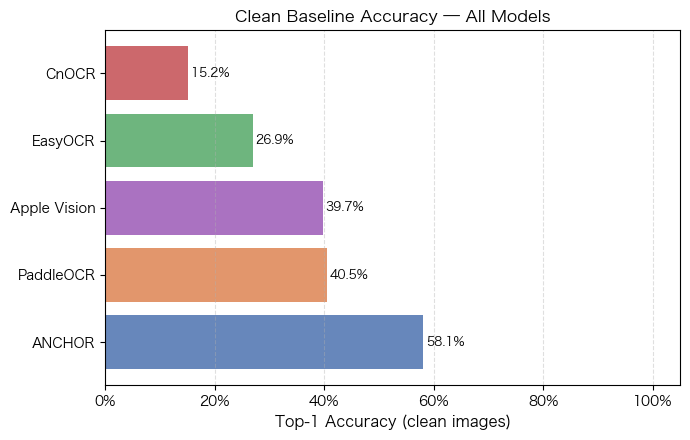

In [6]:
plot_clean_comparison(results_dict, save_path=f"{OUT_DIR}/fig_clean_comparison.png")

Saved to ../outputs/fig_accuracy_by_perturbation.png


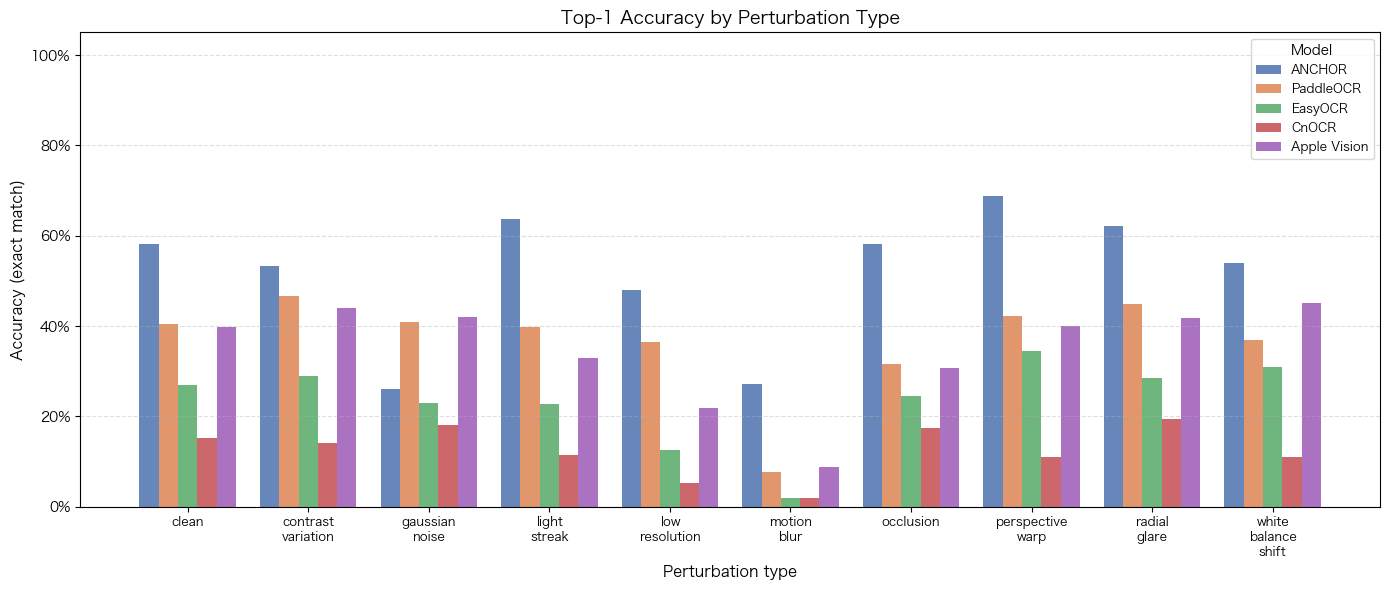

In [7]:
plot_accuracy_by_perturbation(results_dict, save_path=f"{OUT_DIR}/fig_accuracy_by_perturbation.png")

Saved to ../outputs/fig_robustness_heatmap.png


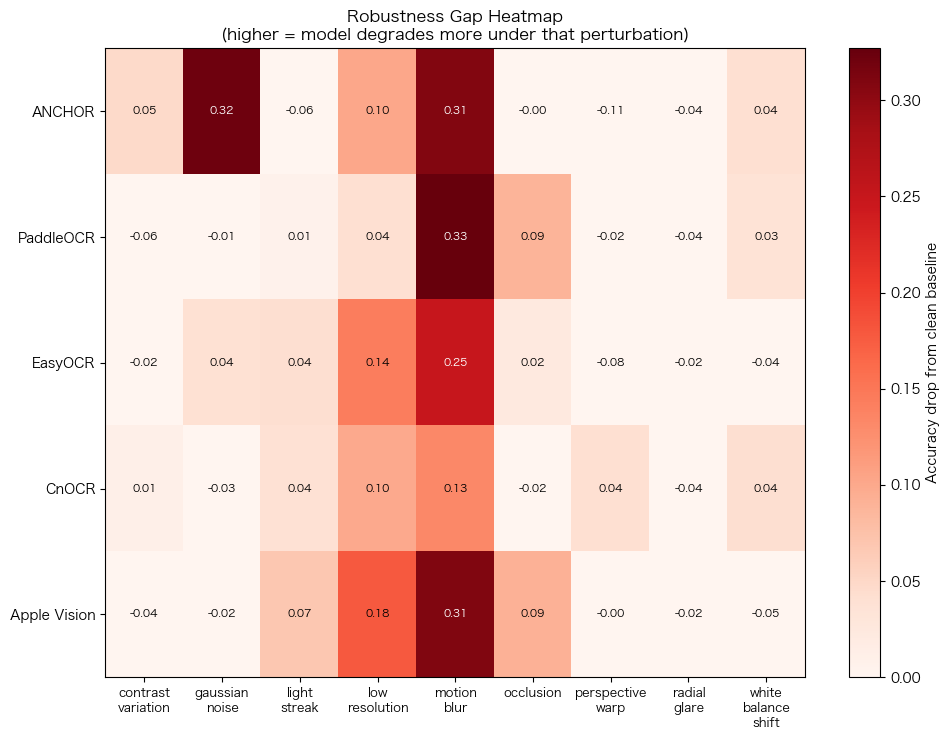

In [8]:
plot_robustness_gap_heatmap(results_dict, save_path=f"{OUT_DIR}/fig_robustness_heatmap.png")

Saved to ../outputs/fig_robustness_gap_bars.png


/Users/eroscarrasco/Documents/IDM/2nd semester/Deep Learning/Final Project/vr-chinese-ocr-eval/evaluation/accuracy_curves.py:197: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Hiragino Sans GB.
  plt.tight_layout()
/Users/eroscarrasco/Documents/IDM/2nd semester/Deep Learning/Final Project/vr-chinese-ocr-eval/evaluation/accuracy_curves.py:200: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Hiragino Sans GB.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Hiragino Sans GB.
  fig.canvas.print_figure(bytes_io, **kw)


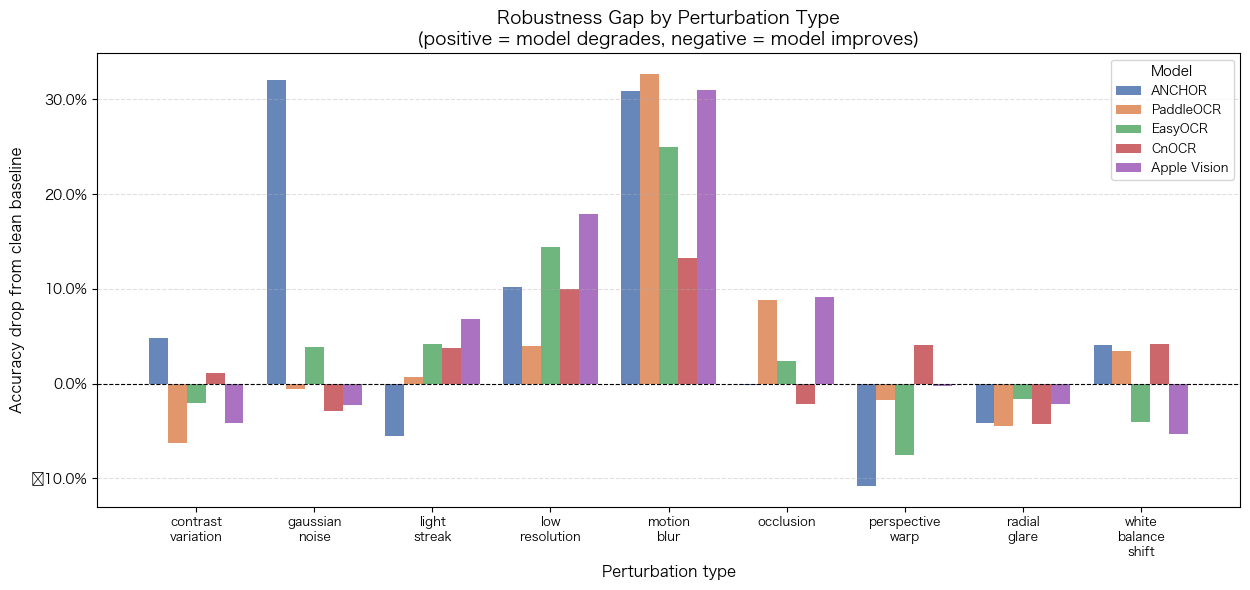

In [9]:
# Bar chart version of the robustness gap — easier to compare magnitudes
plot_robustness_gap_bars(results_dict, save_path=f"{OUT_DIR}/fig_robustness_gap_bars.png")

Saved to ../outputs/fig_f1_by_perturbation.png


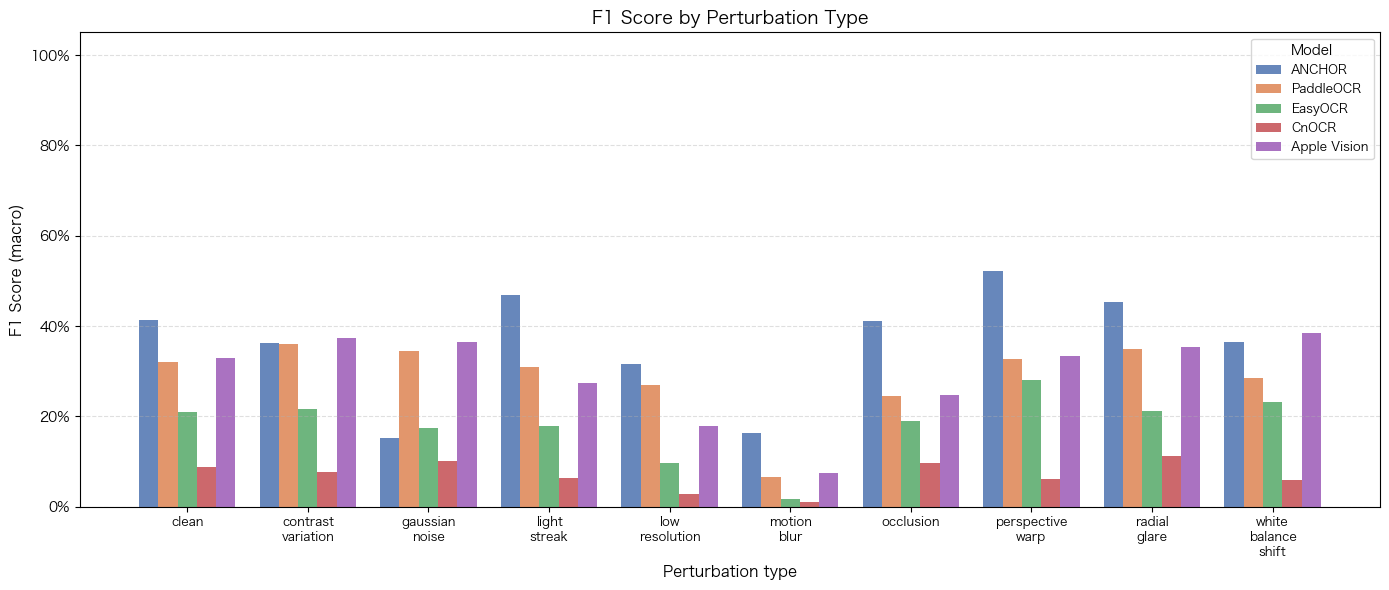

In [10]:
plot_f1_by_perturbation(results_dict, save_path=f"{OUT_DIR}/fig_f1_by_perturbation.png")

Saved to ../outputs/fig_overall_metrics.png


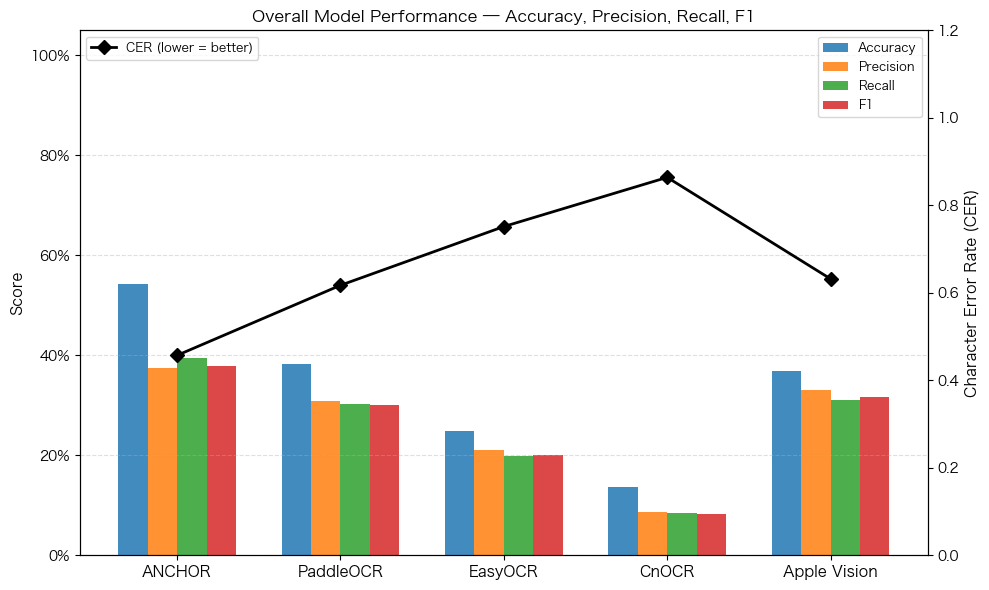

In [11]:
plot_overall_metrics(results_dict, save_path=f"{OUT_DIR}/fig_overall_metrics.png")

## 7. Confusion Matrices

Filtered to the **top-20 most frequent characters** in the test set.  
Each cell = row-normalized recall (diagonal = correct, off-diagonal = confusions).

In [12]:
def plot_confusion_matrix_topn(
    y_true, y_pred, model_name, top_n=20, subset_label="all", ax=None, save_path=None
):
    y_true = np.asarray(y_true, dtype=object)
    y_pred = np.asarray(y_pred, dtype=object)

    top_chars = [c for c, _ in Counter(y_true.tolist()).most_common(top_n)]
    mask = np.isin(y_true, top_chars)
    y_t  = y_true[mask]
    y_p  = np.where(np.isin(y_pred[mask], top_chars), y_pred[mask], "other")

    col_labels = top_chars + ["other"]
    cm = confusion_matrix(y_t, y_p, labels=col_labels)
    cm = cm[: len(top_chars), :]

    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm  = np.where(row_sums > 0, cm / row_sums, 0.0)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(14, 11))

    sns.heatmap(
        cm_norm, annot=True, fmt=".2f",
        xticklabels=col_labels, yticklabels=top_chars,
        cmap="Blues", vmin=0, vmax=1,
        linewidths=0.3, linecolor="#e0e0e0", ax=ax,
    )
    ax.set_title(f"{model_name}  ({subset_label}, top {top_n} chars)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Ground Truth", fontsize=10)
    ax.set_xlabel("Predicted", fontsize=10)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)

    if standalone:
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()

print("Helper defined.")

Helper defined.


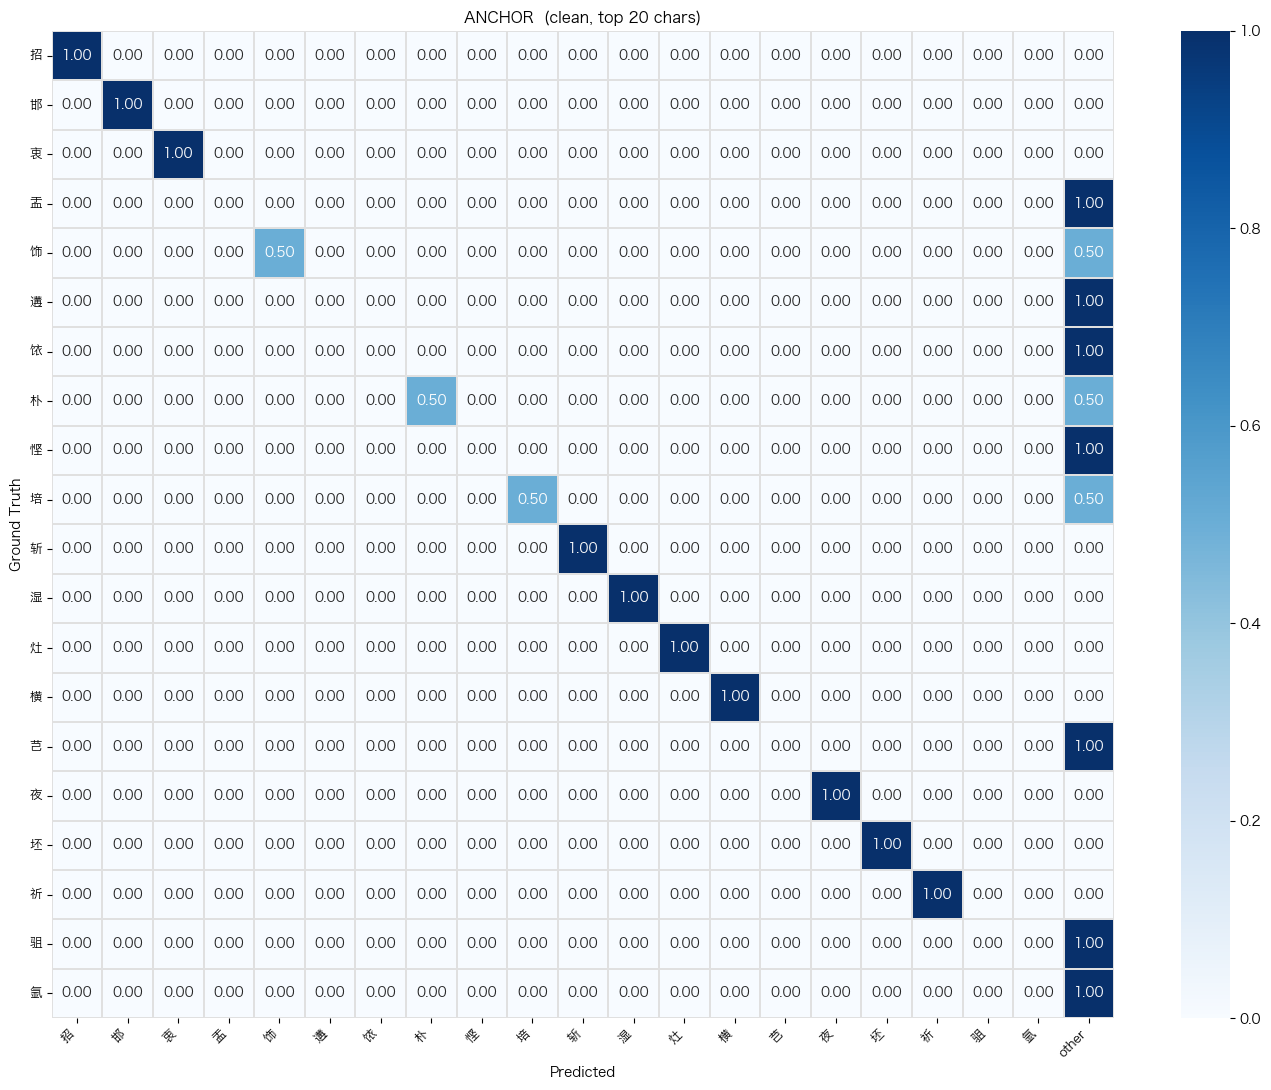

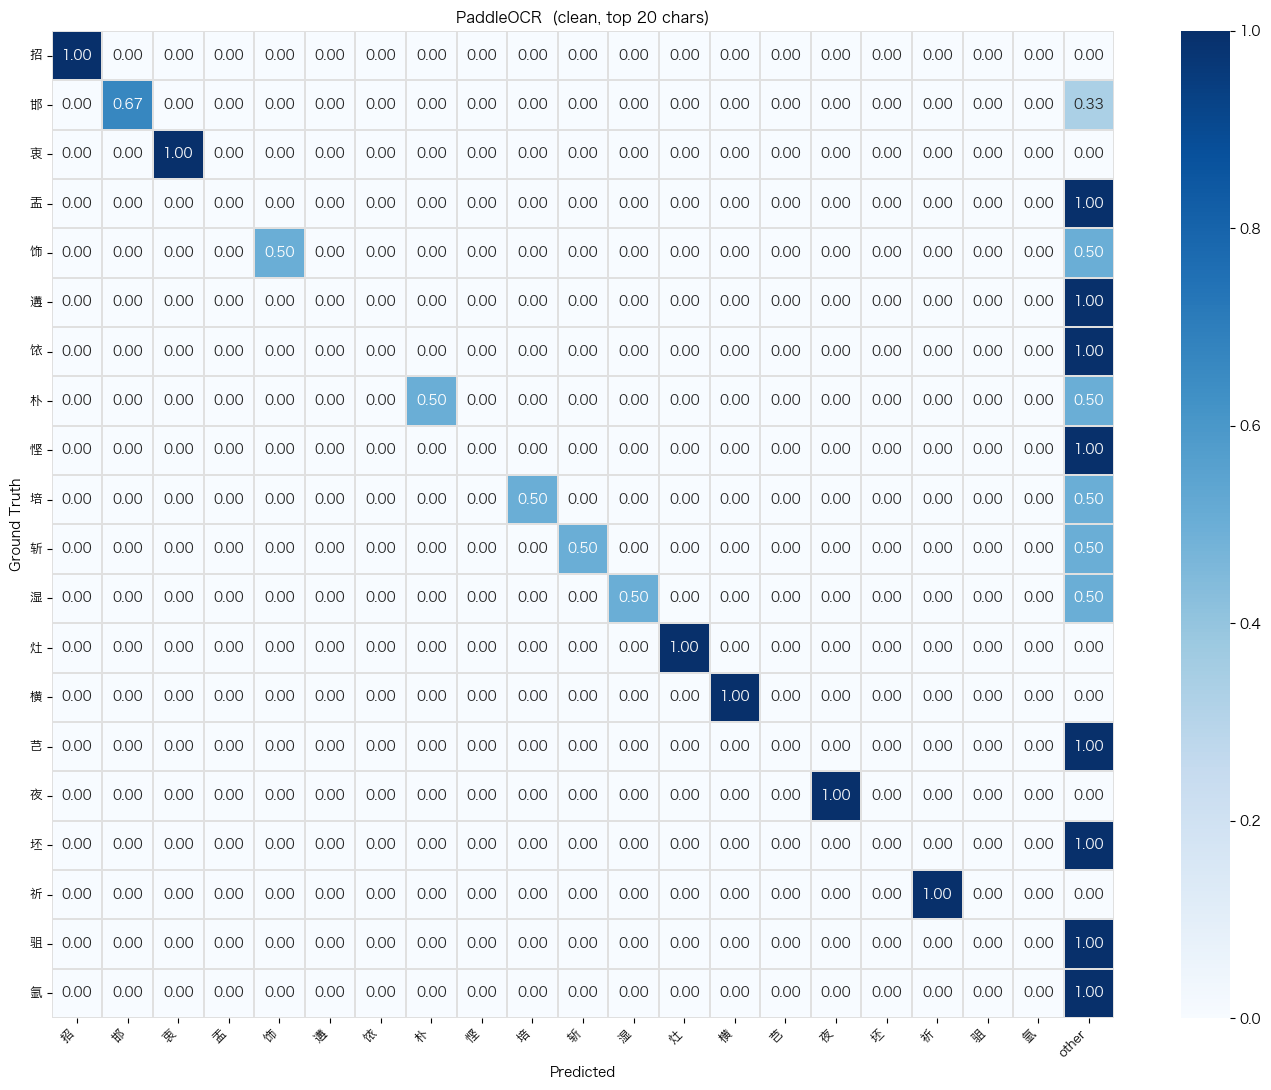

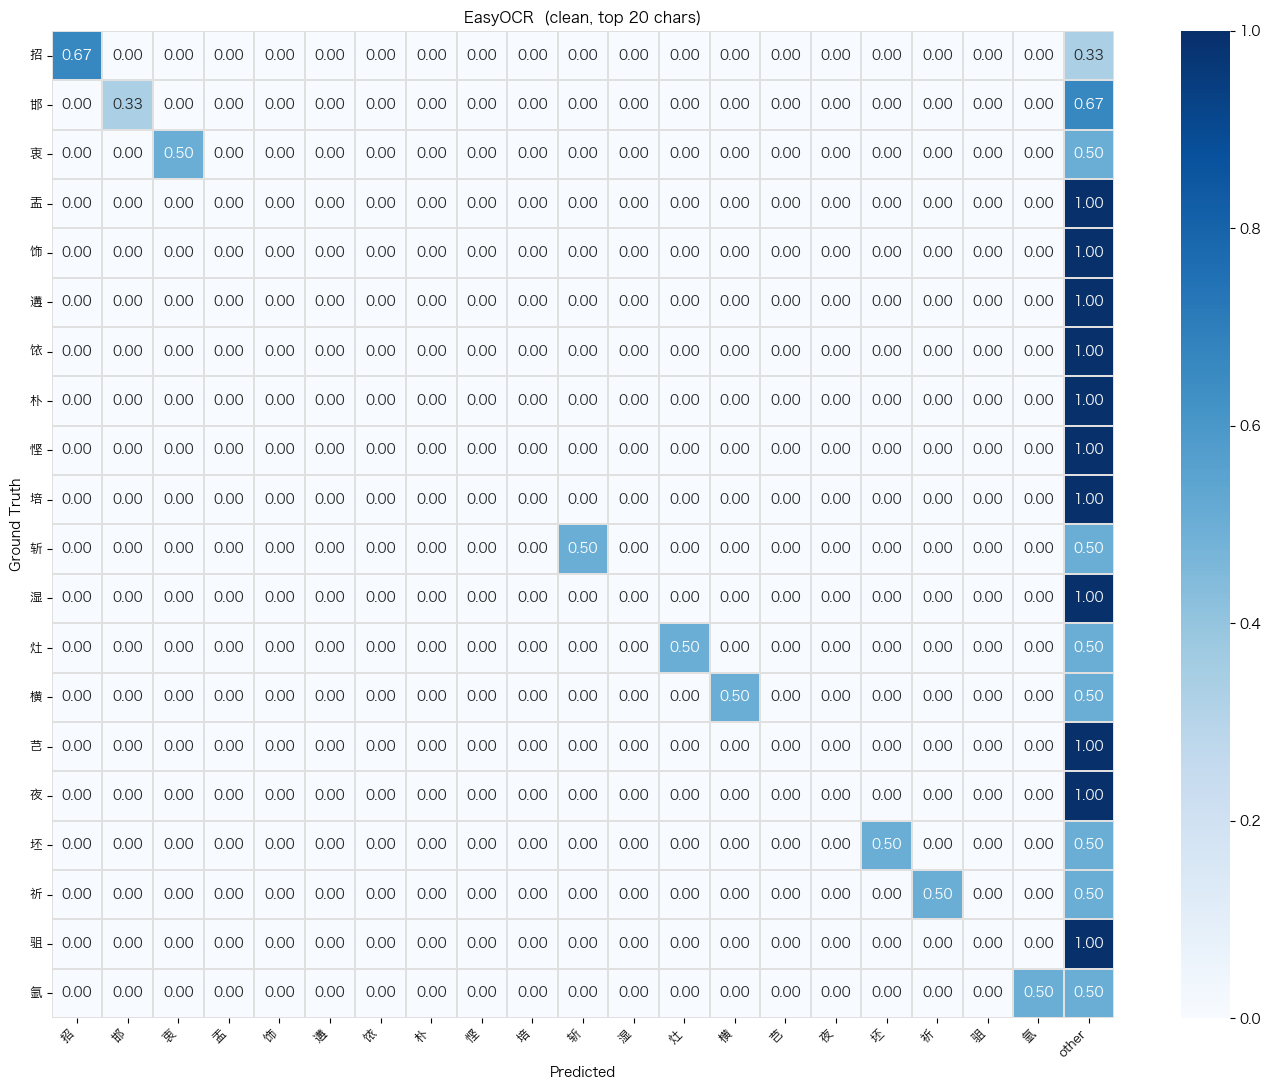

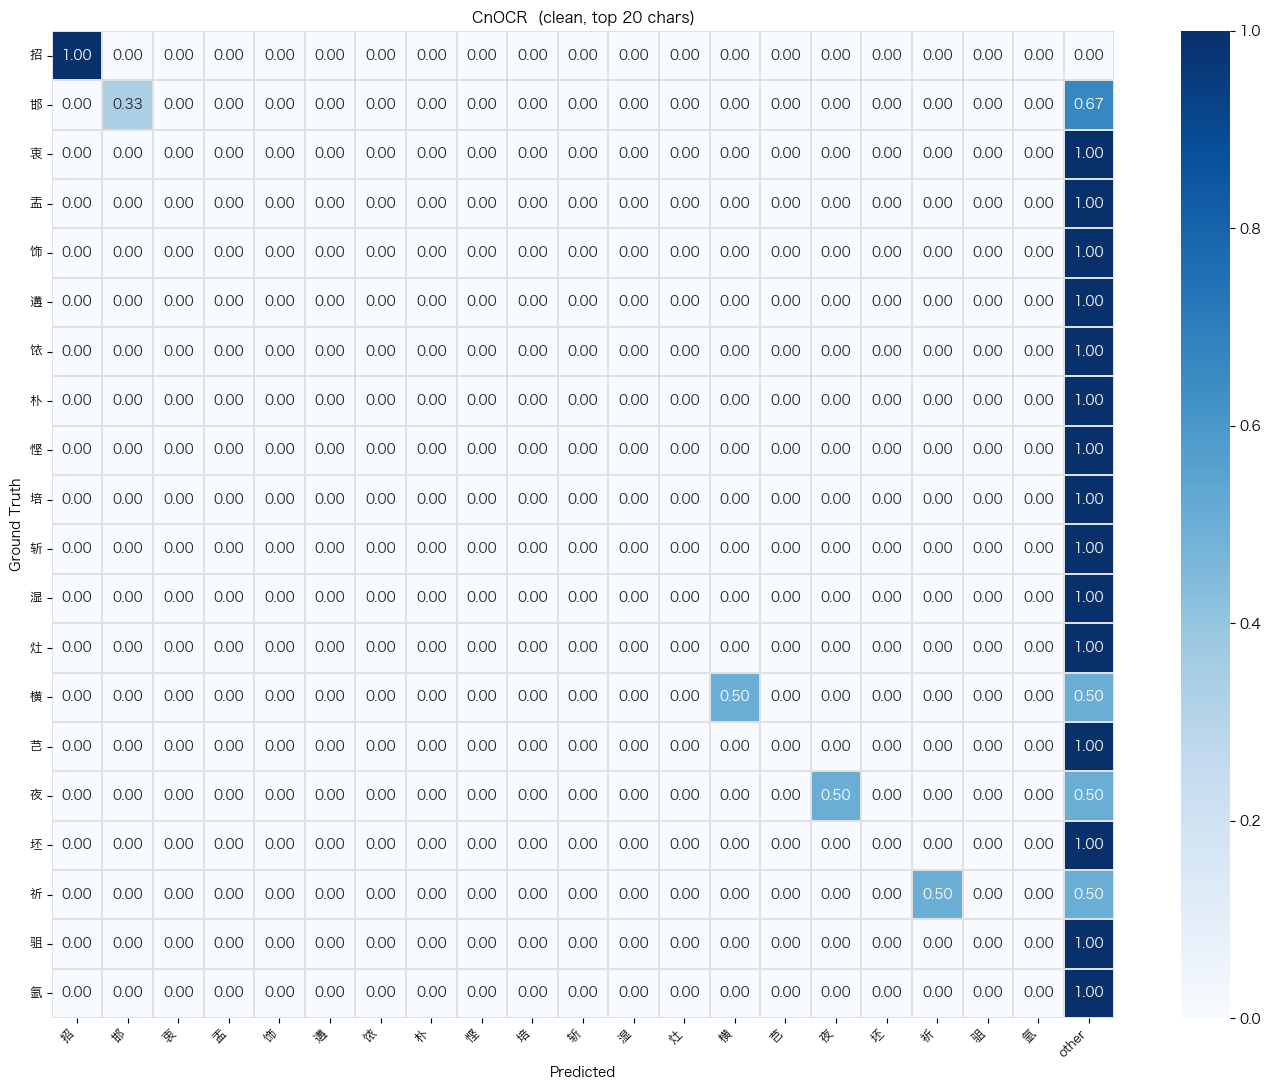

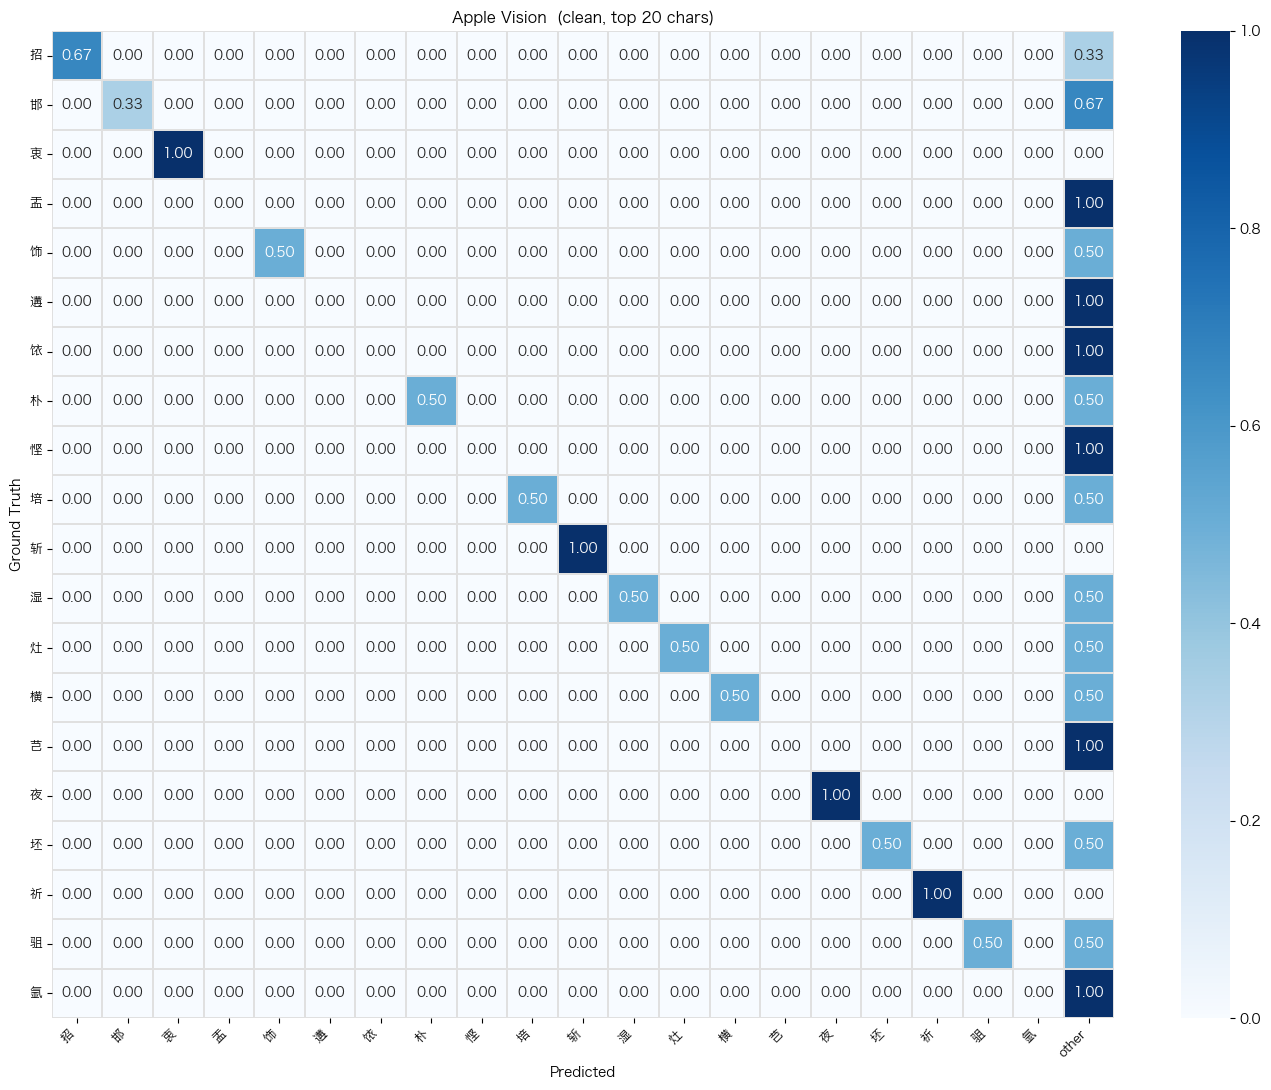

In [13]:
clean_mask = pert_labels == "clean"

for name, pred in preds.items():
    safe_name = name.lower().replace(" ", "_")
    plot_confusion_matrix_topn(
        y_test[clean_mask], pred[clean_mask],
        model_name=name, top_n=20, subset_label="clean",
        save_path=f"{OUT_DIR}/fig_confusion_{safe_name}_clean.png",
    )

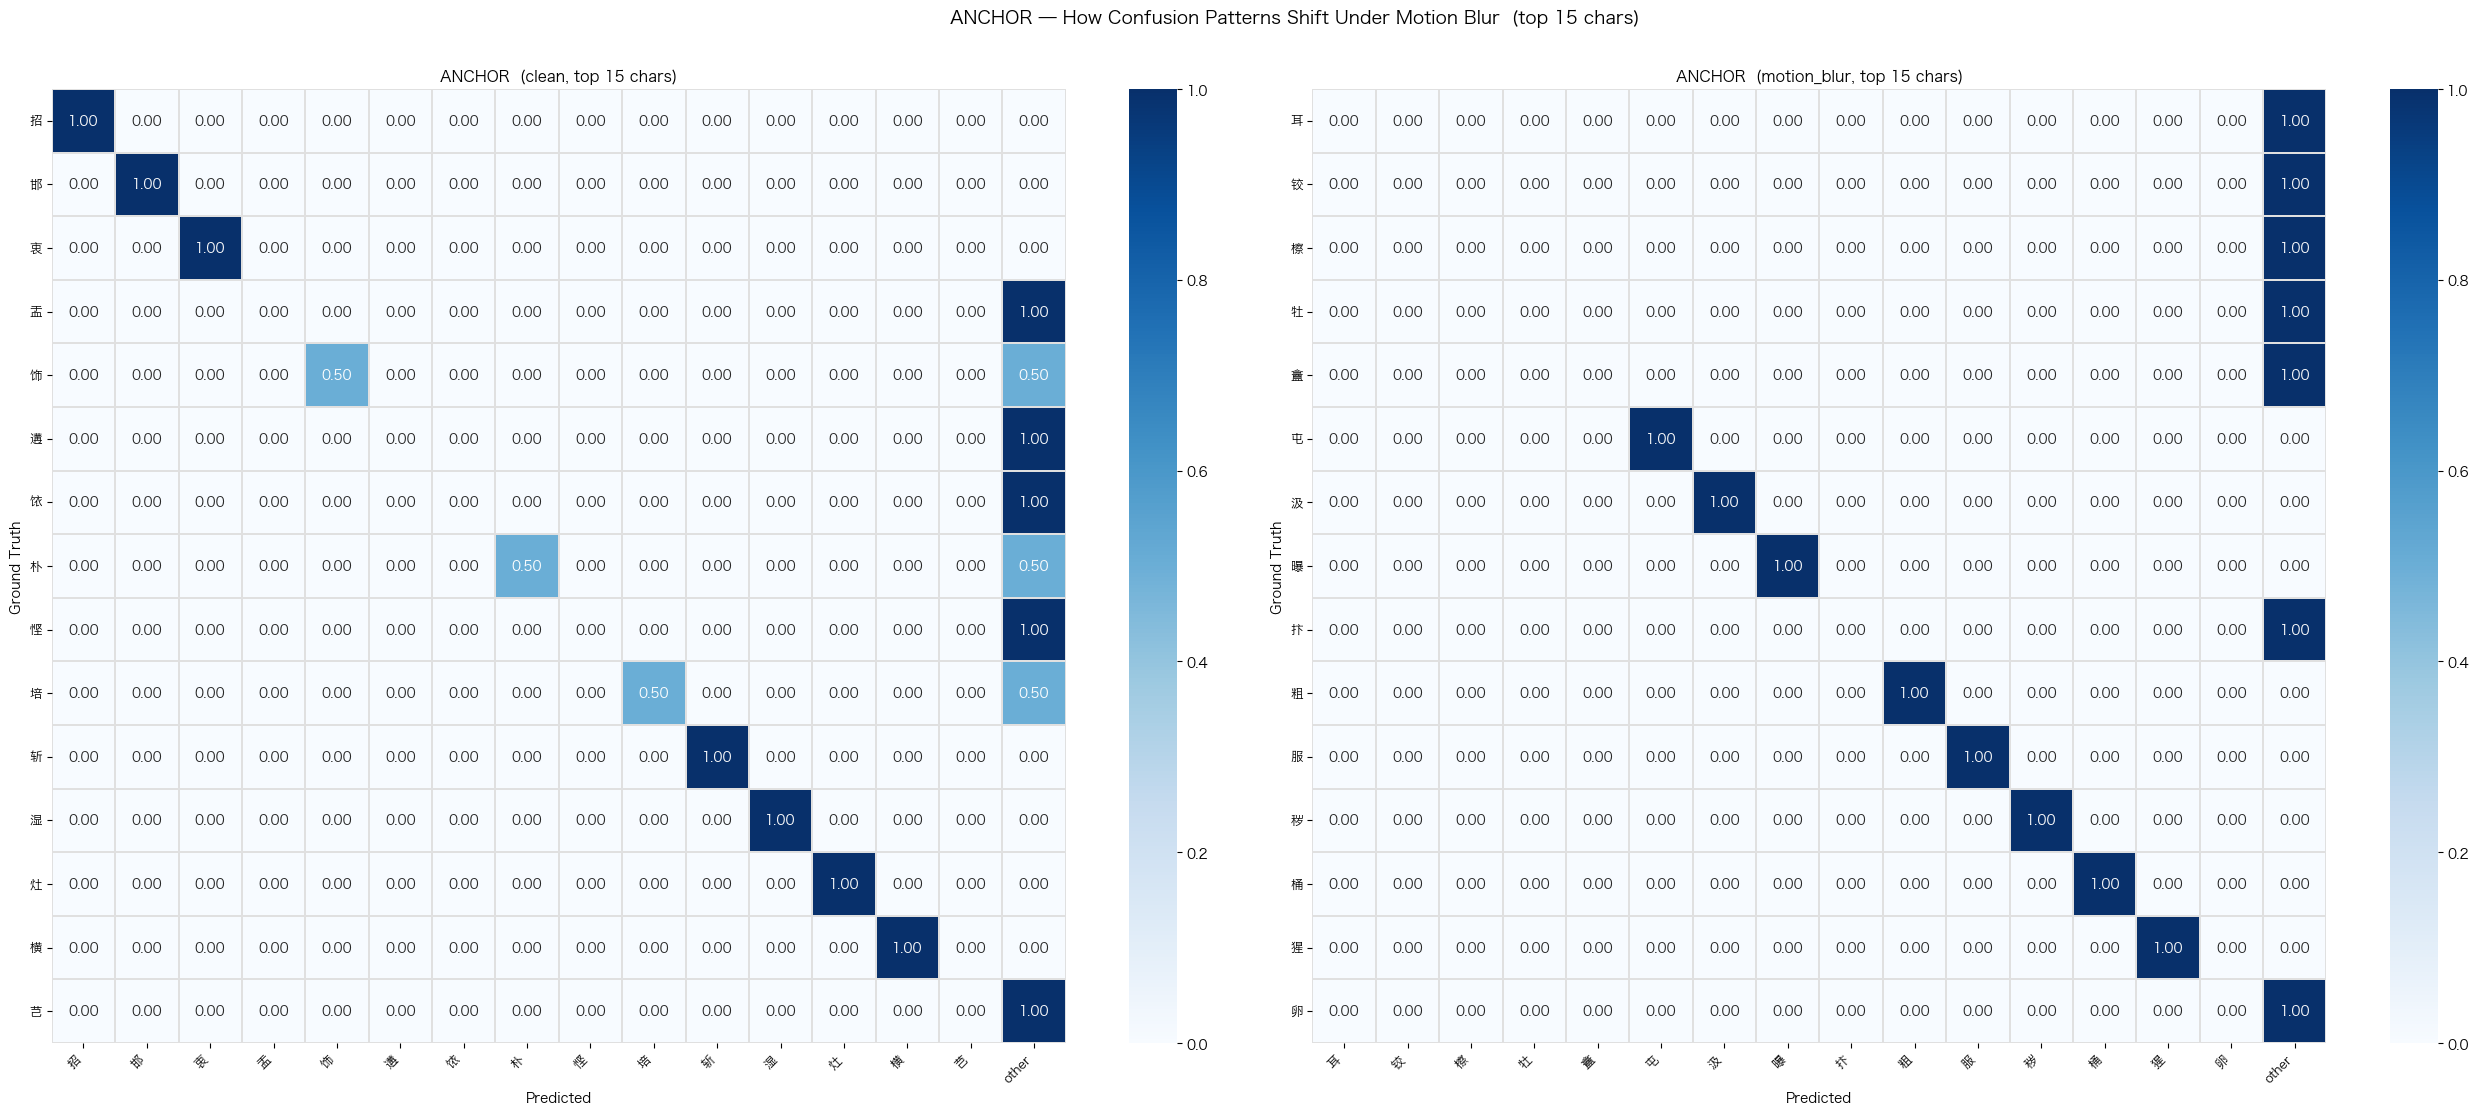

In [14]:
# ANCHOR: how confusion shifts from clean → motion_blur
blur_mask = pert_labels == "motion_blur"

fig, axes = plt.subplots(1, 2, figsize=(26, 11))
for ax, (mask, label) in zip(axes, [(clean_mask, "clean"), (blur_mask, "motion_blur")]):
    plot_confusion_matrix_topn(
        y_test[mask], preds["ANCHOR"][mask],
        model_name="ANCHOR", top_n=15, subset_label=label, ax=ax,
    )
fig.suptitle(
    "ANCHOR — How Confusion Patterns Shift Under Motion Blur  (top 15 chars)",
    fontsize=13, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_anchor_confusion_clean_vs_blur.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Failure Analysis

### 8a. Which samples does every model fail on?

In [15]:
failure_analysis = compare_model_failures(y_test, preds)


Model failure overlap (1698 total samples):
  All models wrong:     535  (31.5%)
  All models correct:    89  (5.2%)
  Only ANCHOR wrong:         4  (0.2%)
  Only PaddleOCR wrong:         4  (0.2%)
  Only EasyOCR wrong:        51  (3.0%)
  Only CnOCR wrong:        90  (5.3%)
  Only Apple Vision wrong:        16  (0.9%)


### 8b. Failure examples per model (saved to outputs/)

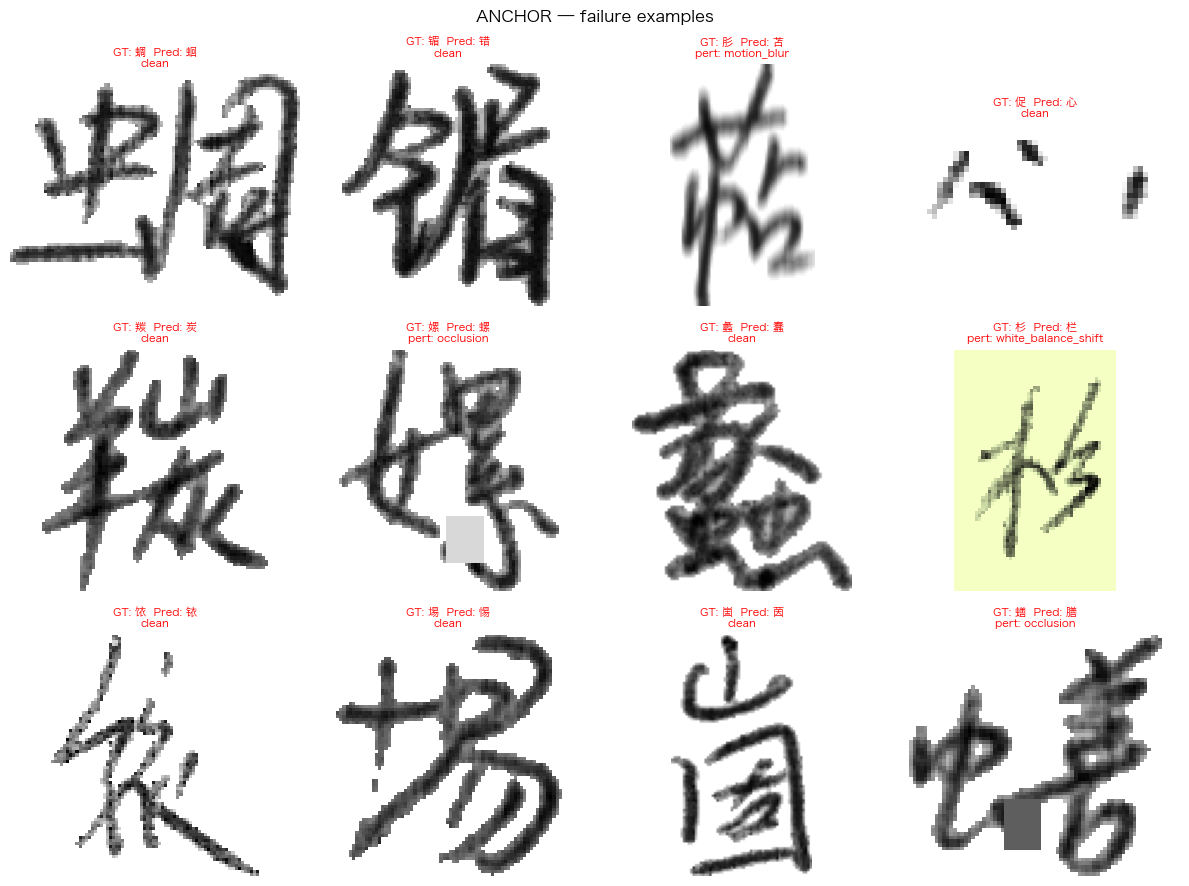

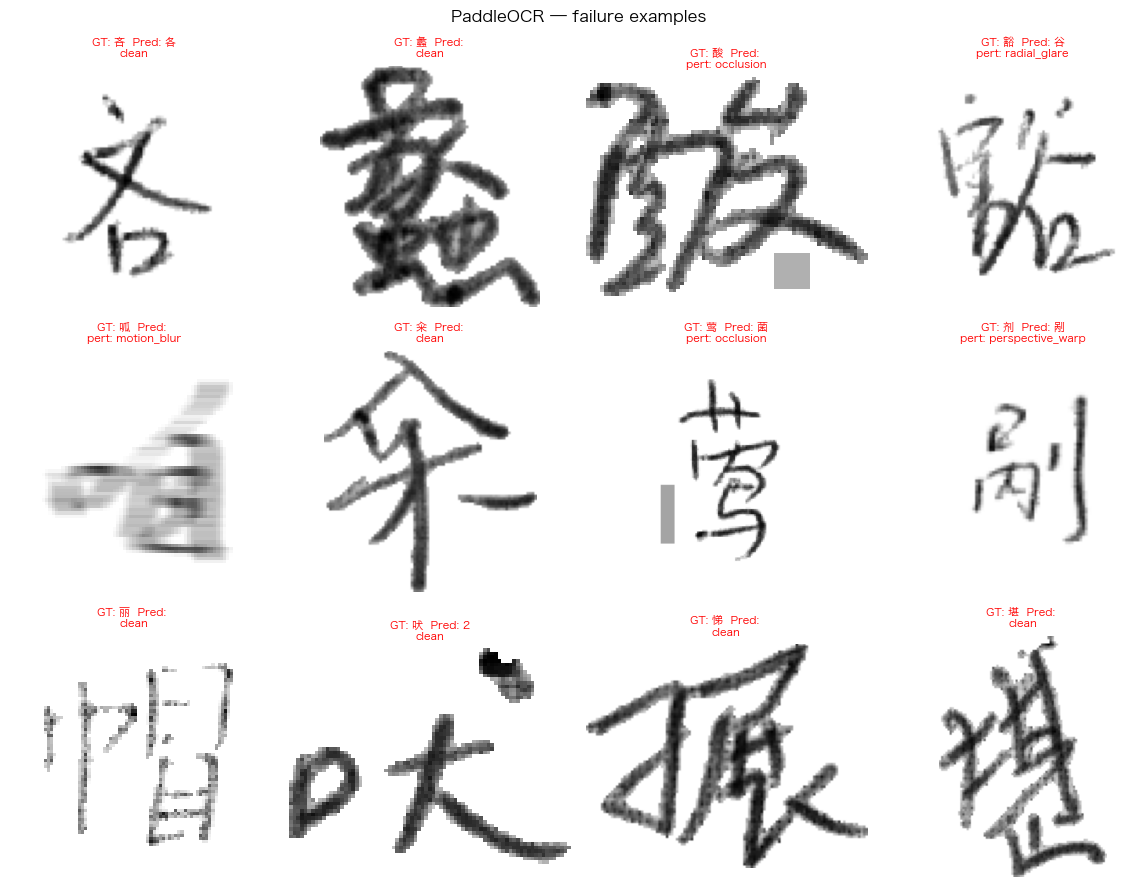

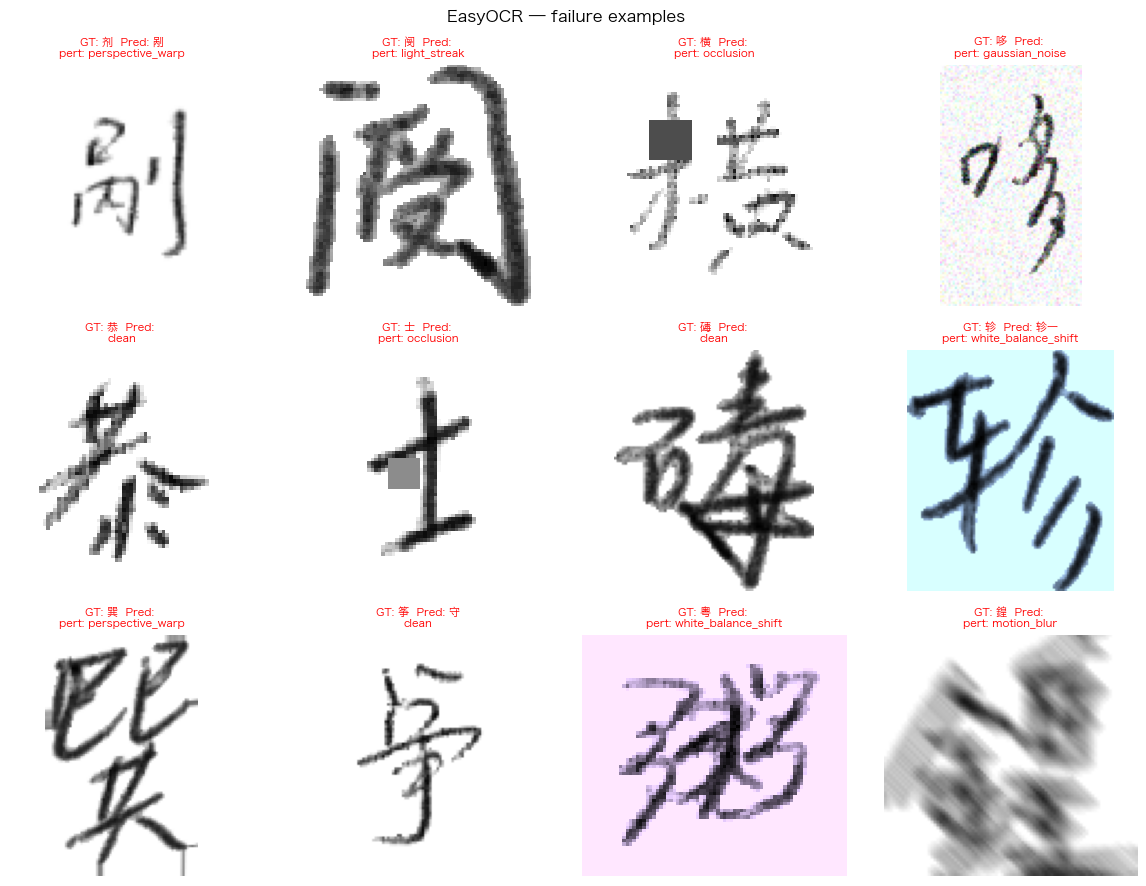

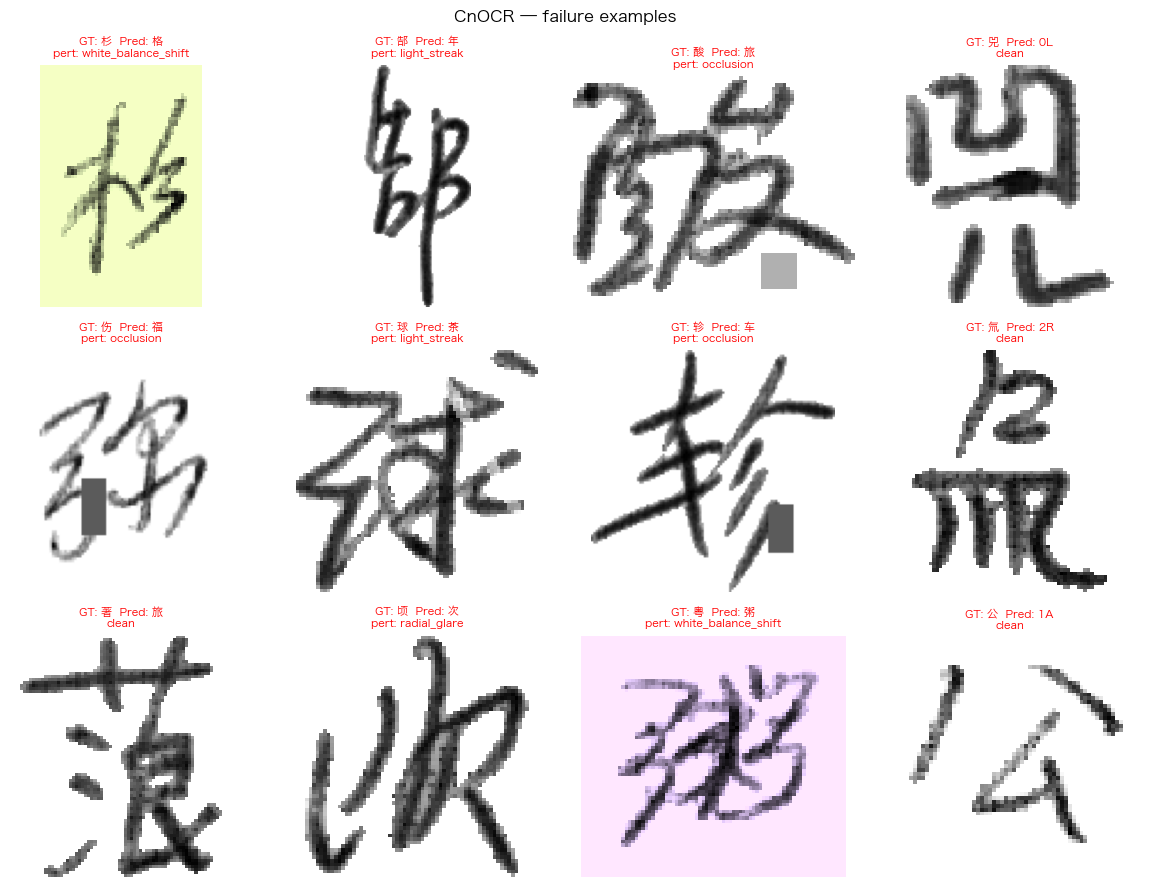

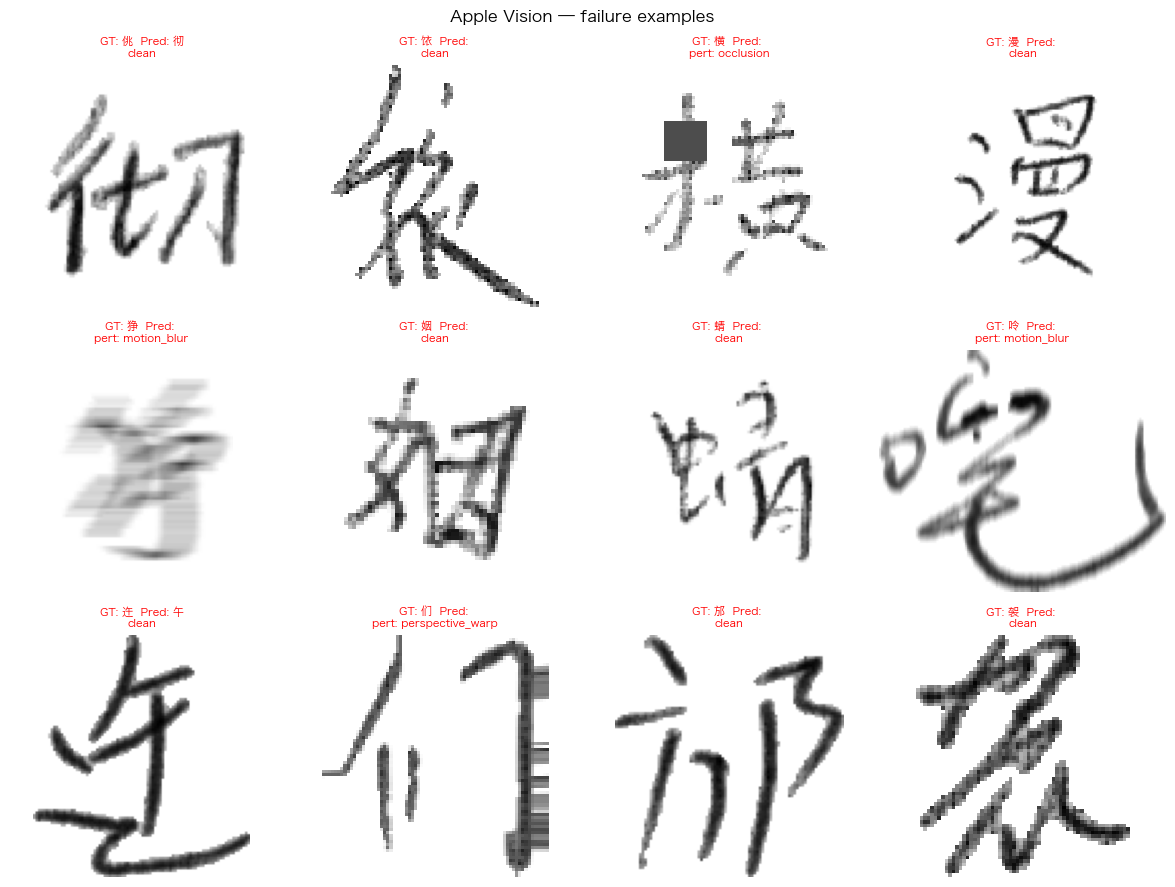

In [16]:
for name, pred in preds.items():
    safe_name = name.lower().replace(" ", "_")
    show_failures(
        X_test, y_test, pred, model_name=name,
        perturbation_types=pert_types, n=12,
        save_path=f"{OUT_DIR}/fig_failures_{safe_name}.png",
    )

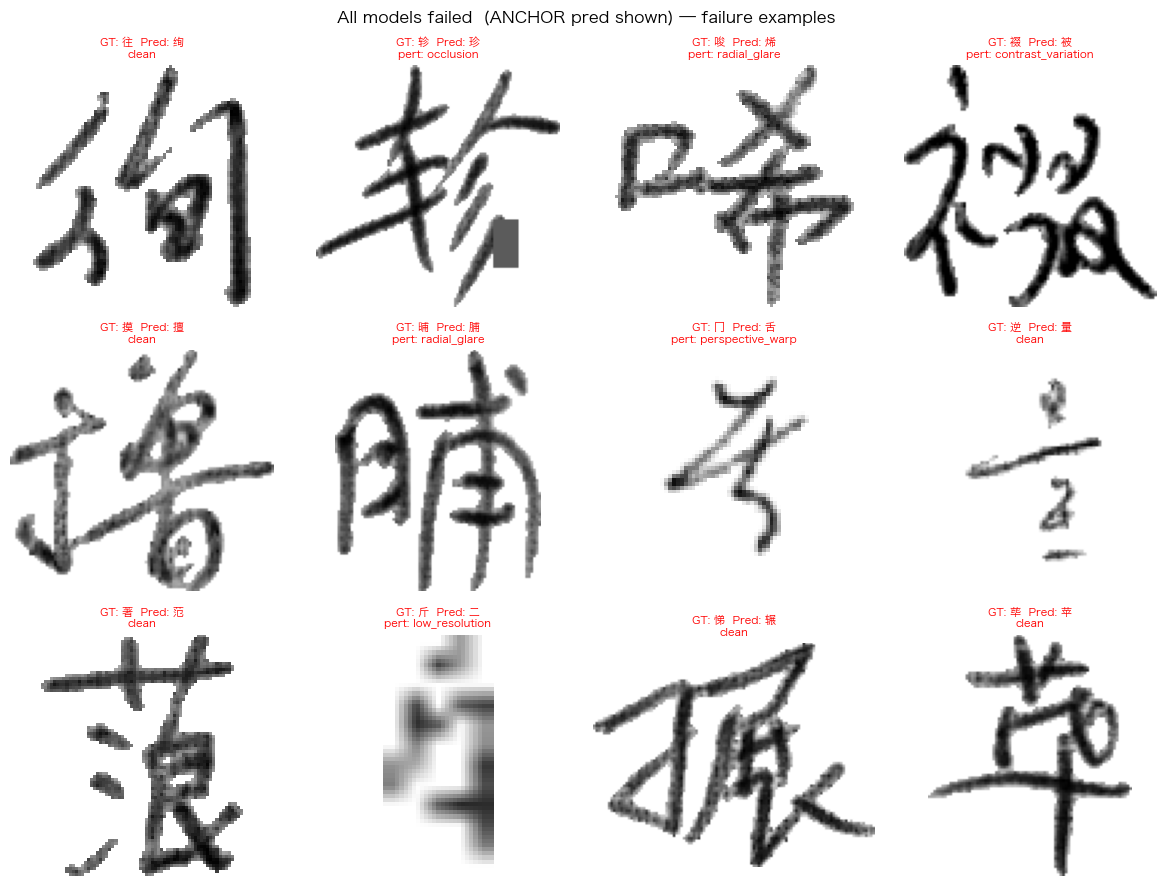

In [17]:
# Samples ALL models fail on — the hardest cases
all_wrong_idx = failure_analysis["all_wrong"]
if len(all_wrong_idx) > 0:
    show_failures(
        X_test[all_wrong_idx], y_test[all_wrong_idx],
        preds["ANCHOR"][all_wrong_idx],
        model_name="All models failed  (ANCHOR pred shown)",
        perturbation_types=pert_types[all_wrong_idx], n=12,
        save_path=f"{OUT_DIR}/fig_failures_all_wrong.png",
    )
else:
    print("No samples that all models fail on.")

### 8c. Top confused character pairs (saved to outputs/)

In [18]:
def save_confused_pairs_figure(y_true, y_pred, model_name, top_n=10, save_path=None):
    """Save top confused character pairs as a styled table figure."""
    # Ensure CJK font is active for this figure
    for _f in _CJK_FONTS:
        if _f in _available_fonts:
            matplotlib.rcParams["font.family"] = _f
            break

    y_true = np.asarray(y_true, dtype=object)
    y_pred = np.asarray(y_pred, dtype=object)

    wrong_mask = y_pred != y_true
    pairs  = list(zip(y_true[wrong_mask], y_pred[wrong_mask]))
    counts = Counter(pairs).most_common(top_n)

    rows = [[gt, pred if str(pred).strip() else "(empty)", cnt]
            for (gt, pred), cnt in counts]

    fig_h = max(3.5, 0.55 * len(rows) + 1.8)
    fig, ax = plt.subplots(figsize=(6, fig_h))
    ax.axis("off")

    tbl = ax.table(
        cellText=rows,
        colLabels=["Ground Truth", "Predicted", "Count"],
        loc="center",
        cellLoc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(13)
    tbl.scale(1.2, 2.0)

    header_color = "#4C72B0"
    for j in range(3):
        tbl[0, j].set_facecolor(header_color)
        tbl[0, j].set_text_props(color="white", fontweight="bold")

    for i in range(1, len(rows) + 1):
        bg = "#f0f4fa" if i % 2 == 0 else "white"
        for j in range(3):
            tbl[i, j].set_facecolor(bg)

    ax.set_title(
        f"{model_name}\nTop {top_n} Confused Character Pairs",
        fontsize=13, fontweight="bold", pad=16,
    )
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

print("Helper defined.")

Helper defined.



ANCHOR — top 8 confused pairs (ground truth → prediction):
    GT    Pred   Count
------------------------
     摒       撒       3
     悭       搭       3
     盂       盐       2
     优       弘       2
     锩       险       2
     銎       鉴       2
     伤       弥       2
     遘       隘       2


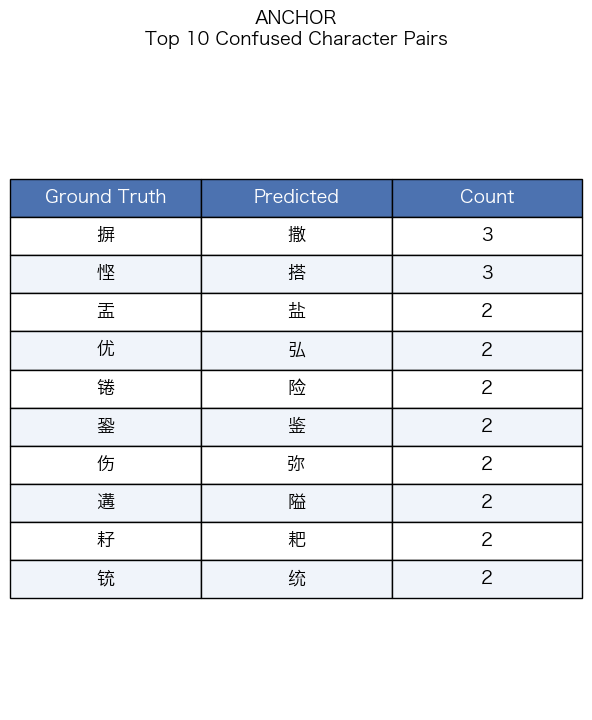


PaddleOCR — top 8 confused pairs (ground truth → prediction):
    GT    Pred   Count
------------------------
     悭       搭       3
     礴               3
     杪               3
     盂       盐       2
     优       弘       2
     锩       险       2
     銎               2
     伤       弥       2


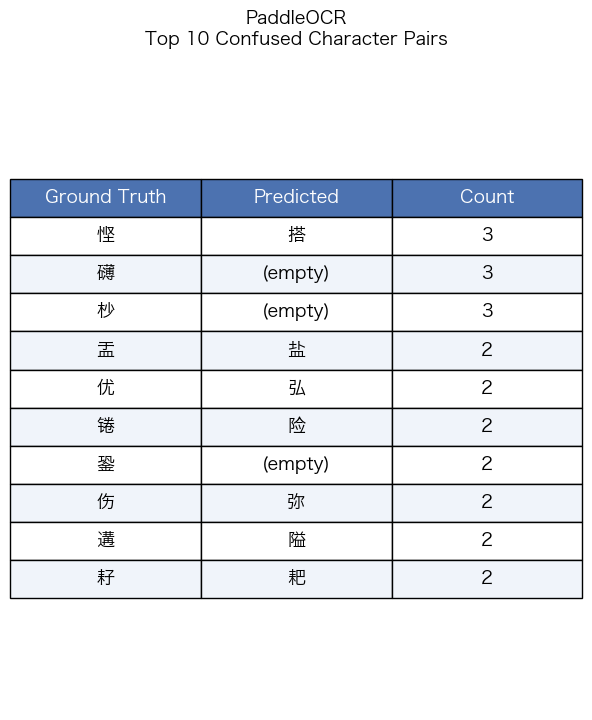


EasyOCR — top 8 confused pairs (ground truth → prediction):
    GT    Pred   Count
------------------------
     屯               4
     杪               3
     卓               3
     与               2
     饰               2
     锩               2
     銎               2
     滴               2


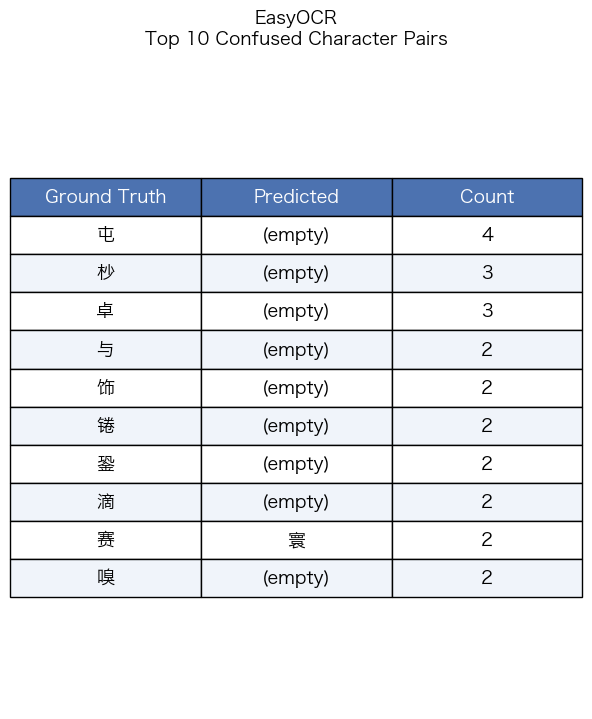


CnOCR — top 8 confused pairs (ground truth → prediction):
    GT    Pred   Count
------------------------
     摒       椒       2
     锩       险       2
     甥       锦       2
     欲       饮       2
     莪       茶       2
     粤       粥       2
     肄       茶       2
     嘛       麻       2


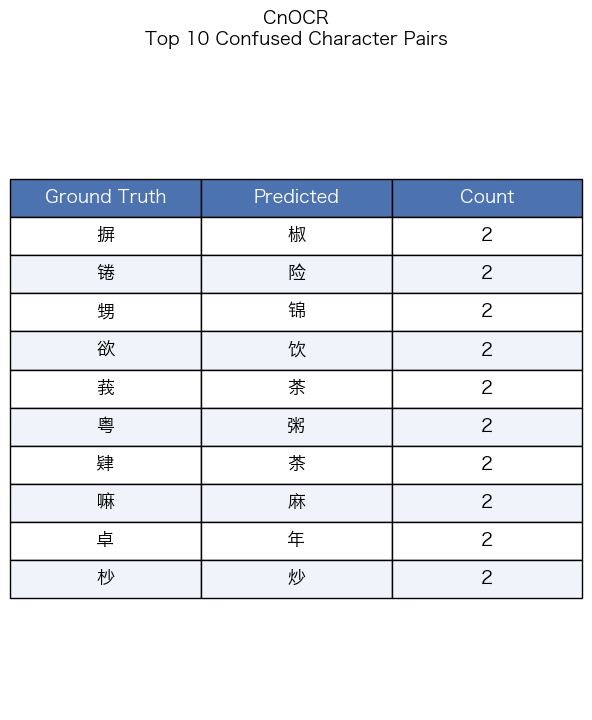


Apple Vision — top 8 confused pairs (ground truth → prediction):
    GT    Pred   Count
------------------------
     摒               2
     盂       盐       2
     惜               2
     檫               2
     銎               2
     冂               2
     闯               2
     剂       剐       2


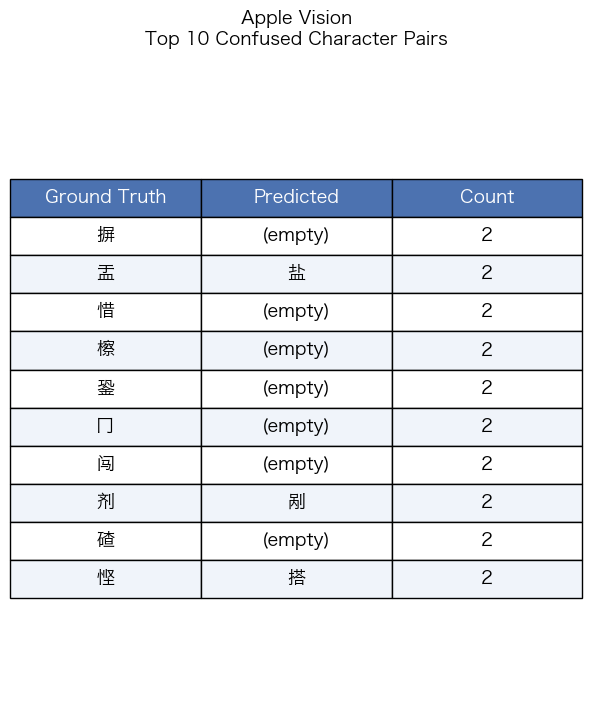

In [19]:
for name, pred in preds.items():
    safe_name = name.lower().replace(" ", "_")
    # Print text version
    confusion_summary(y_test, pred, model_name=name, top_n=8)
    # Save figure version
    save_confused_pairs_figure(
        y_test, pred, model_name=name, top_n=10,
        save_path=f"{OUT_DIR}/fig_confused_pairs_{safe_name}.png",
    )